<a href="https://colab.research.google.com/github/Suvyaktha-M/Machine-Learning-Lab/blob/main/Task-9/Task_9_Post_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##POST LAB

========== CNN RESULTS ==========
Test Accuracy: 1.0
Test Loss: 0.0


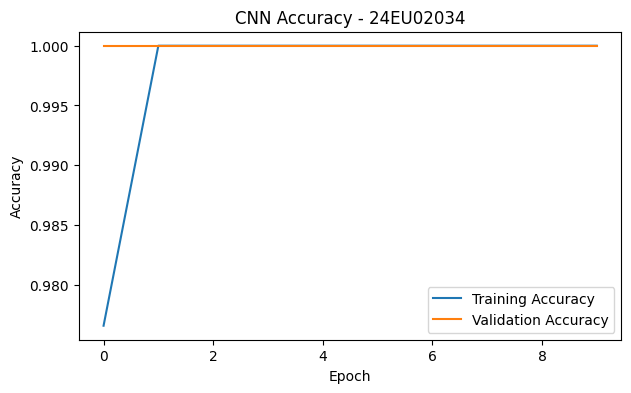


========== RNN RESULTS ==========
Test Accuracy: 1.0
Test Loss: 0.0016


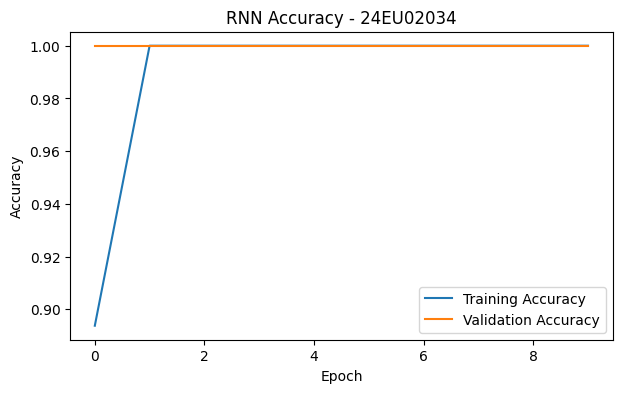

In [2]:
# ============================================================
# CNN AND RNN ON OWN DATASETS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.layers import SimpleRNN, Dropout

# ============================================================
# 1. CNN - Own Dataset
# Dataset: Synthetic signal classification
# Class 0 -> Low-frequency signal
# Class 1 -> High-frequency signal
# ============================================================

np.random.seed(42)

samples = 1000
timesteps = 100

X_cnn = []
y_cnn = []

for i in range(samples):
    t = np.linspace(0, 1, timesteps)

    if i < samples // 2:
        # Class 0: Low-frequency signal
        signal = np.sin(2 * np.pi * 5 * t)
        label = 0
    else:
        # Class 1: High-frequency signal
        signal = np.sin(2 * np.pi * 20 * t)
        label = 1

    # Add noise
    signal = signal + np.random.normal(0, 0.2, timesteps)

    X_cnn.append(signal)
    y_cnn.append(label)

X_cnn = np.array(X_cnn)
y_cnn = np.array(y_cnn)

# Shuffle dataset
indices = np.random.permutation(samples)
X_cnn = X_cnn[indices]
y_cnn = y_cnn[indices]

# CNN requires 3D input: samples, timesteps, features
X_cnn = X_cnn.reshape(samples, timesteps, 1)

# Train-test split
split = int(0.8 * samples)

X_train = X_cnn[:split]
X_test = X_cnn[split:]

y_train = y_cnn[:split]
y_test = y_cnn[split:]

# Build CNN using modern Input layer
cnn = Sequential([
    Input(shape=(timesteps, 1)),
    Conv1D(32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train CNN
cnn_history = cnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Evaluate CNN
cnn_loss, cnn_accuracy = cnn.evaluate(X_test, y_test, verbose=0)

print("========== CNN RESULTS ==========")
print("Test Accuracy:", round(cnn_accuracy, 4))
print("Test Loss:", round(cnn_loss, 4))

# CNN Accuracy Graph
plt.figure(figsize=(7, 4))
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy - 24EU02034')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# ============================================================
# 2. RNN - Own Dataset
# Dataset: Synthetic time-series classification
# Class 0 -> Increasing trend
# Class 1 -> Decreasing trend
# ============================================================

samples = 1000
timesteps = 20

X_rnn = []
y_rnn = []

for i in range(samples):

    if i < samples // 2:
        # Class 0: Increasing sequence
        sequence = np.linspace(0, 1, timesteps)
        label = 0

    else:
        # Class 1: Decreasing sequence
        sequence = np.linspace(1, 0, timesteps)
        label = 1

    # Add noise
    sequence = sequence + np.random.normal(0, 0.05, timesteps)

    X_rnn.append(sequence)
    y_rnn.append(label)

X_rnn = np.array(X_rnn)
y_rnn = np.array(y_rnn)

# Shuffle dataset
indices = np.random.permutation(samples)
X_rnn = X_rnn[indices]
y_rnn = y_rnn[indices]

# RNN requires 3D input:
# samples, timesteps, features
X_rnn = X_rnn.reshape(samples, timesteps, 1)

# Train-test split
split = int(0.8 * samples)

X_train = X_rnn[:split]
X_test = X_rnn[split:]

y_train = y_rnn[:split]
y_test = y_rnn[split:]

# Build RNN using modern Input layer
rnn = Sequential([
    Input(shape=(timesteps, 1)),
    SimpleRNN(32, activation='tanh'),

    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train RNN
rnn_history = rnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Evaluate RNN
rnn_loss, rnn_accuracy = rnn.evaluate(X_test, y_test, verbose=0)

print("\n========== RNN RESULTS ==========")
print("Test Accuracy:", round(rnn_accuracy, 4))
print("Test Loss:", round(rnn_loss, 4))

# RNN Accuracy Graph
plt.figure(figsize=(7, 4))
plt.plot(rnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('RNN Accuracy - 24EU02034')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()